# **TS6:** Primeras nociones de estimación espectral: Ancho de banda de señales.
## Mariano Pittaluga.

En el repositorio PDStestbench encontrará tres tipos de señales registradas:

- Electrocardiograma (ECG). En el archivo ECG_TP4.mat encontrará un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas más abajo.
- Pletismografía (PPG). El archivo PPG.csv contiene una señal registrada en reposo de un estudiante de la materia que ha donado su registro para esta actividad.
- Audio. Tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.

Los detalles de cómo acceder a dichos registros los pueden encontrar en lectura_sigs.py

Se pide:

1) Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

2) Realice una estimación del ancho de banda de cada señal y presente los resultados en un tabla para facilitar la comparación.

Bonus:

    - Proponga algún tipo de señal que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.
    
## Resolución:
## Función Ancho de Banda:
La función calcula la potencia total de la señal y busca los puntos entre los cuales la potencia equivale a un porcentaje de la total definida por la "cota".

In [67]:
def bandWidth(psd, deltaf, tipo = 'passband', cota = 0.95):
    cumP = np.cumsum(psd)*deltaf
    Pt = cumP[-1]
    cumP /= Pt
    match tipo:
        case 'passband':
            idx_fo  = np.argmin(np.abs(cumP - 0.5))
            idx_fcs = np.argmin(np.abs(cumP - (1 + cota)/2))
            idx_fci = np.argmin(np.abs(cumP - (1 - cota)/2))
        case 'lowpass':
            idx_fo  = 0
            idx_fcs = np.argmin(np.abs(cumP - cota))
            idx_fci = 0
            
    fo  = deltaf*idx_fo
    fcs = deltaf*idx_fcs
    fci = deltaf*idx_fci
    
    B = fcs - fci 
    return B, fo, fcs, fci;

### Analisis de Electrocardiograma (ECG):
#### Periodograma Ventaneado:
En principio realizamos una estimación de la densidad espectral de potencia con el metodo más simple, el periodograma. Antes de realizar el periodograma aplicamos una ventana a la señal. En este caso, seleccionamos unaa ventana flattop. El periodograma nos permitira comparar con los otros dos metodos que implementaremos mas adelante para observar la mejora de la varianza en los gráficos.
#### ECG Muestreado

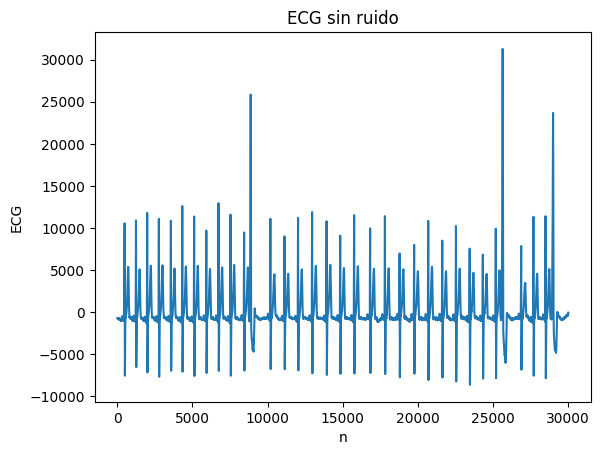

In [68]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt 
import scipy.io as sio

fs_ecg = 1000 # Hz
ecg_one_lead = np.load('ecg_sin_ruido.npy')
ecg_one_lead = ecg_one_lead - np.mean(ecg_one_lead) # Elimino la potencia de continua.
Necg = len(ecg_one_lead)
deltaf_ecg = fs_ecg/Necg
cota = 0.99 # Cota de potencia para ancho de banda

plt.figure()
plt.xlabel('n')
plt.ylabel('ECG')
plt.title('ECG sin ruido')
plt.plot(ecg_one_lead)

#### Metodo de Welch:
Se divide la señal original en bloques de menor tamaño. Estos pueden superponerse. Luego se le aplica una ventadna y se calcula el periodograma a cada bloque individualmente. Finalmente, se realiza un promedio con todos los bloques. Dos parametros importantes en este metodo son el porcentaje de superposicion y la cantidad de bloques. En nuestro caso la superposicion es del 50%. El valor de K (cantidad de bloques) se selecciona teniendo en cuenta que puntos de interese puede tener una señal. 
##### Etapa de Selección de K:
Planteamos cuatro valores de K y seleccionamos el de nuestra preferencia. Para el ECG selecccionamos K = 6 ya que presentaba un buen balance entre una menor varianza y suficiente resolución espectral.

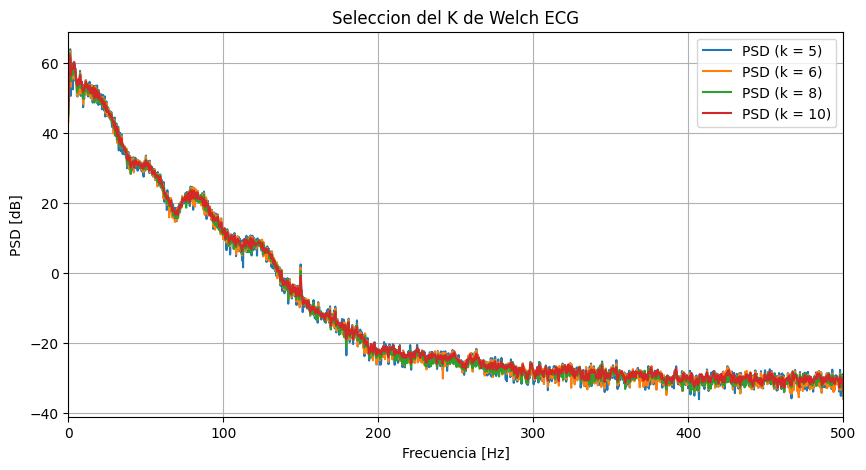

In [69]:
K = [5, 6, 8, 10]

fecg_k1, Pecg_wk1 = sig.welch(ecg_one_lead, fs_ecg, nperseg=Necg/K[0], return_onesided = True)
fecg_k2, Pecg_wk2 = sig.welch(ecg_one_lead, fs_ecg, nperseg=Necg/K[1], return_onesided = True)
fecg_k3, Pecg_wk3 = sig.welch(ecg_one_lead, fs_ecg, nperseg=Necg/K[2], return_onesided = True)
fecg_k4, Pecg_wk4 = sig.welch(ecg_one_lead, fs_ecg, nperseg=Necg/K[3], return_onesided = True)

plt.figure(figsize=(10,5))
plt.plot(fecg_k1,10*np.log10(Pecg_wk1), label=f'PSD (k = {K[0]})')
plt.plot(fecg_k2,10*np.log10(Pecg_wk2), label=f'PSD (k = {K[1]})')
plt.plot(fecg_k3,10*np.log10(Pecg_wk3), label=f'PSD (k = {K[2]})')
plt.plot(fecg_k4,10*np.log10(Pecg_wk4), label=f'PSD (k = {K[3]})')


plt.xlim([0, fs_ecg//2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Seleccion del K de Welch ECG')
plt.legend()
plt.grid()
plt.show()
#%% Calculo de ancho de Banda ECG Welch
Pecg_w = Pecg_wk2
fecg_w = fecg_k2
k = 6
deltaf_ecg_w = fecg_w[1] - fecg_w[0] 
Becg_w, fo_ecg_w, fcs_ecg_w, fci_ecg_w = bandWidth(Pecg_w, deltaf = deltaf_ecg_w, tipo = 'lowpass',  cota = cota)

#### Metodo de Blackman-Tuckey:
Se le aplica a la autocorrelación de la señal una ventana de menor tamaño que la misma, truncando los valores de lag mayores. Finalmente, se le aplica la fft a autocorrelacion resultante. El parametro a seleccionar es el tamaño de la ventana (M). Este nos define la relación de compromiso entre resolución espectral y la varianza. Aplicamos un criterio similar al de la K de Welch para seleccionar el valor de M. Se concluye que el mejor M es que corresponde a N//3.

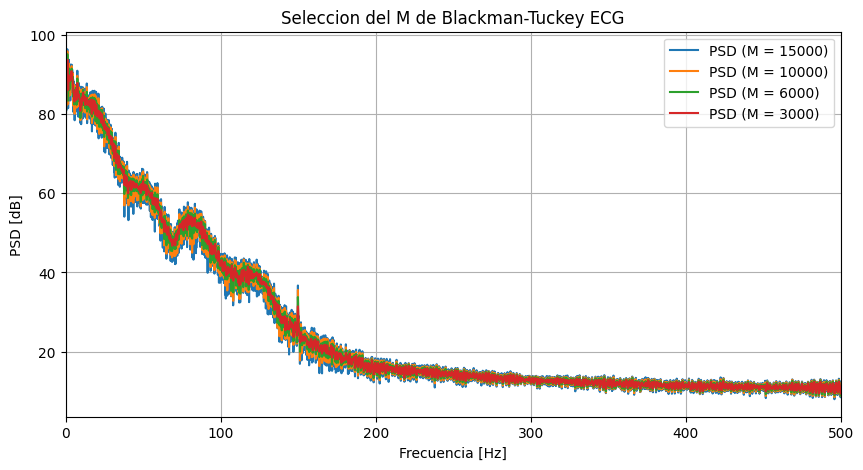

In [70]:
def blackman_tukey(x, fs, M = None):    
    
    N = len(x)

    if M is None:
        M = N//5
        
    r_len = 2*M-1

    rxx = np.correlate(x, x, mode='full') / N

    # Recorto a lo afectado por la ventana
    mid = len(rxx) // 2
    rxx = rxx[mid-(M-1):mid+M]

    #Blackman
    w = sig.windows.blackman(r_len)/ np.mean(sig.windows.blackman(r_len))
    rxx_w = rxx * w

    # PSD
    Px = np.abs(np.fft.fft(rxx_w))
    
    #f = np.arange(start = 0, stop = fs, step = fs/r_len)
    f = np.linspace(0, fs, r_len, endpoint=False)

    return f, Px;
    
#%% Etapa de seleccion de M
M = [Necg//2, Necg//3, Necg//5, Necg//10]

fecg_M1, Pecg_btM1 = blackman_tukey(ecg_one_lead,  fs = fs_ecg, M = M[0])
fecg_M2, Pecg_btM2 = blackman_tukey(ecg_one_lead,  fs = fs_ecg, M = M[1])
fecg_M3, Pecg_btM3 = blackman_tukey(ecg_one_lead,  fs = fs_ecg, M = M[2])
fecg_M4, Pecg_btM4 = blackman_tukey(ecg_one_lead,  fs = fs_ecg, M = M[3])

plt.figure(figsize=(10,5))
plt.plot(fecg_M1,10*np.log10(Pecg_btM1), label=f'PSD (M = {M[0]})')
plt.plot(fecg_M2,10*np.log10(Pecg_btM2), label=f'PSD (M = {M[1]})')
plt.plot(fecg_M3,10*np.log10(Pecg_btM3), label=f'PSD (M = {M[2]})')
plt.plot(fecg_M4,10*np.log10(Pecg_btM4), label=f'PSD (M = {M[3]})')

plt.xlim([0, fs_ecg//2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Seleccion del M de Blackman-Tuckey ECG')
plt.legend()
plt.grid()
plt.show()

Pecg_bt = Pecg_btM2
fecg_bt = fecg_M2
m = M[1]
deltaf_ecg_bt = fecg_bt[1] - fecg_bt[0] 
Becg_bt, fo_ecg_bt, fcs_ecg_bt, fci_ecg_bt = bandWidth(Pecg_bt[:m], deltaf = deltaf_ecg_bt, tipo = 'lowpass',  cota = cota)

#### Graficos de PSD de un ECG:

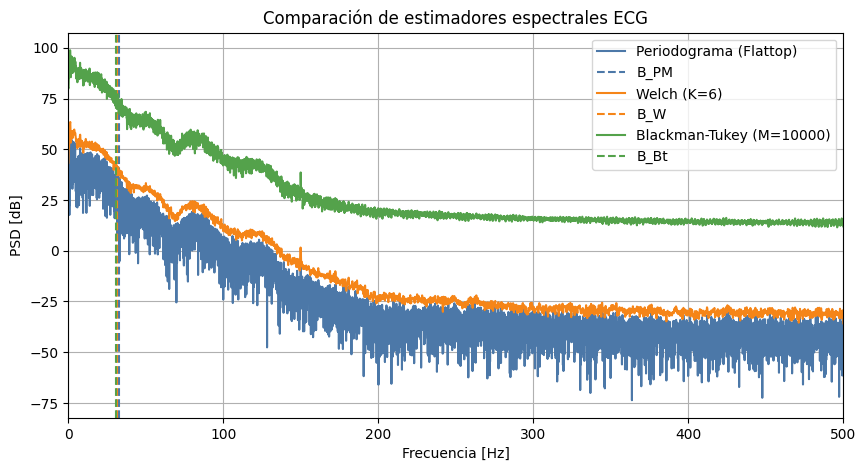


  Señal    |       Método       | Bandwidth [Hz] 
--------------------------------------------------
   ECG     |    Periodograma    |           32.57
   ECG     |       Welch        |           31.20
   ECG     |   Blackman-Tukey   |           30.85


In [71]:
plt.figure(figsize=(10,5))
color_pm = '#4C78A8'   # azul suave
color_w  = '#F58518'   # naranja suave
color_bt = '#54A24B'   # verde suave

# Periodograma ventaneado
plt.plot(f_ecg_pm,10*np.log10(2*Pecg_pm),label='Periodograma (Flattop)',color=color_pm)
plt.axvline(fcs_ecg_pm, color=color_pm, linestyle='--', label='B_PM')

# Welch
plt.plot(fecg_w,10*np.log10(Pecg_w),label=f'Welch (K={k})', color=color_w)
plt.axvline(fcs_ecg_w, color=color_w, linestyle='--', label='B_W')

# Blackman-Tukey
plt.plot(fecg_bt,10*np.log10(2*Pecg_bt),label=f'Blackman-Tukey (M={m})', color=color_bt)
plt.axvline(fcs_ecg_bt, color=color_bt, linestyle='--', label='B_Bt')


plt.xlim([0, fs_ecg/2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Comparación de estimadores espectrales ECG')
plt.grid(True)
plt.legend()
plt.show() 

print("\n{:^10} | {:^18} | {:^15}".format(
      "Señal", "Método", "Bandwidth [Hz]"))
print("-"*50)

datos = [
    ("ECG",   "Periodograma",   Becg_pm),
    ("ECG",   "Welch",          Becg_w),
    ("ECG",   "Blackman-Tukey", Becg_bt),
]

for señal, metodo, bw in datos:
    print(f"{señal:^10} | {metodo:^18} | {bw:>15.2f}")

En principio, podemos observar la enorme varianza que presenta el periodograma frente a los otros dos metodos. Notamos que el metodo de Wlech aparenta ser el de menor varianza entre los tres. Debemos tener en cuenta que esto depende de los valores de M y K seleccionados. El metodo de Blackman-Tukey presenta una sobreestimacion de casi 50 db en toda la banda. Asimismo, parece concentrar la potencia en las frecuencias mas bajas. Esto lo confirmamos obsservando que es el que menor ancho de banda presenta.

### Analisis de Pletismografía (PPG):
#### Periodograma Ventaneado y PPG Muestreado:

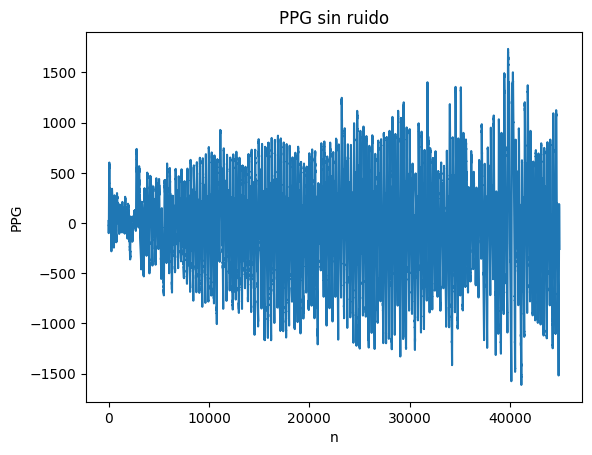

In [72]:
fs_ppg = 400 # Hz
ppg = np.load('ppg_sin_ruido.npy')
ppg = ppg - np.mean(ppg) # Elimino la potencia de continua.
Nppg = len(ppg)
deltaf_ppg = fs_ppg/Nppg

plt.figure()
plt.xlabel('n')
plt.ylabel('PPG')
plt.title('PPG sin ruido')
plt.plot(ppg)

#%% PPG con Periodograma ventaneado
ppg_pm = ppg * sig.windows.flattop(Nppg)/ np.mean(sig.windows.flattop(Nppg))
PPG_pm = np.fft.fft(ppg_pm, axis = 0)/Nppg
f_ppg_pm = np.arange(start = 0, stop = fs_ppg, step = deltaf_ppg)
Pppg_pm = np.abs(PPG_pm)**2

#Calculo de ancho de Banda
Bppg_pm, fo_ppg_pm, fcs_ppg_pm, fci_ppg_pm = bandWidth(Pppg_pm[:Nppg//2], deltaf = deltaf_ppg, tipo = 'lowpass',  cota = cota)

#### Metodo de Welch:
##### Etapa de Selección de K:
Planteamos cuatro valores de K y seleccionamos el de nuestra preferencia. Para el PPG selecccionamos K = 8 ya que presentaba un buen balance entre una menor varianza y suficiente resolución espectral para discriminar los detalles.

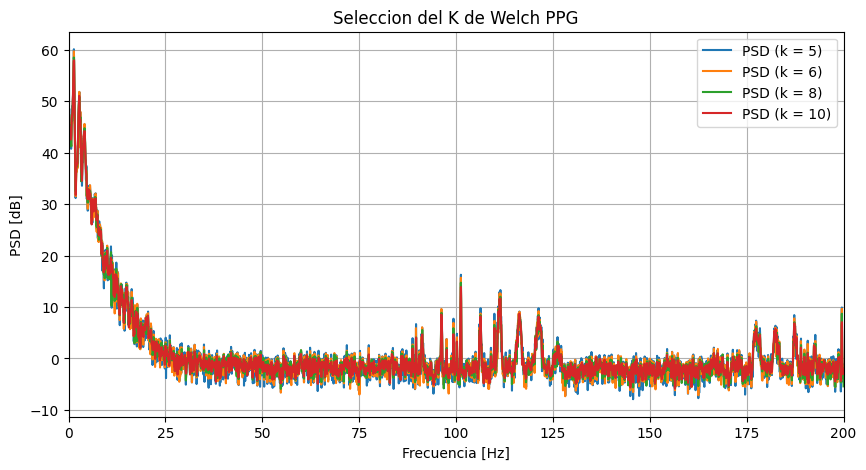

In [73]:
#%% Etapa de seleccion de K
Kppg = [5, 6, 8, 10]

fppg_k1, Pppg_wk1 = sig.welch(ppg, fs_ppg, nperseg=Nppg/Kppg[0], return_onesided = True)
fppg_k2, Pppg_wk2 = sig.welch(ppg, fs_ppg, nperseg=Nppg/Kppg[1], return_onesided = True)
fppg_k3, Pppg_wk3 = sig.welch(ppg, fs_ppg, nperseg=Nppg/Kppg[2], return_onesided = True)
fppg_k4, Pppg_wk4 = sig.welch(ppg, fs_ppg, nperseg=Nppg/Kppg[3], return_onesided = True)

plt.figure(figsize=(10,5))
plt.plot(fppg_k1,10*np.log10(Pppg_wk1), label=f'PSD (k = {Kppg[0]})')
plt.plot(fppg_k2,10*np.log10(Pppg_wk2), label=f'PSD (k = {Kppg[1]})')
plt.plot(fppg_k3,10*np.log10(Pppg_wk3), label=f'PSD (k = {Kppg[2]})')
plt.plot(fppg_k4,10*np.log10(Pppg_wk4), label=f'PSD (k = {Kppg[3]})')


plt.xlim([0, fs_ppg//2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Seleccion del K de Welch PPG')
plt.legend()
plt.grid()
plt.show()
#%% Calculo de ancho de Banda PPG Welch
Pppg_w = Pppg_wk2
fppg_w = fppg_k2
kppg = 8
deltaf_ppg_w = fppg_w[1] - fppg_w[0] 
Bppg_w, fo_ppg_w, fcs_ppg_w, fci_ppg_w = bandWidth(Pppg_w, deltaf = deltaf_ppg_w, tipo = 'lowpass',  cota = cota)

#### Metodo de Blackman-Tuckey:
Planteamos cuatro valores de M en funcion de N y seleccionamos el de nuestra preferencia. Para el PPG selecccionamos M = N/3 ya que presentaba un buen balance entre una menor varianza y suficiente resolución espectral para discriminar los detalles.

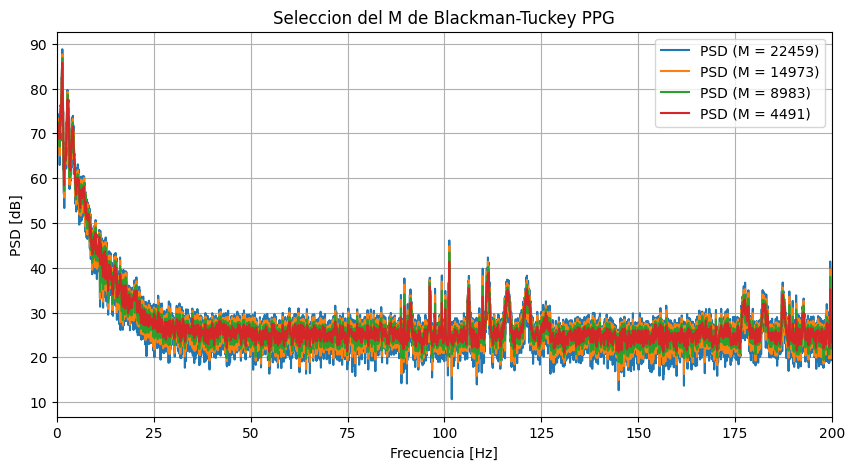

In [74]:
#%% Etapa de seleccion de M
Mppg = [Nppg//2, Nppg//3, Nppg//5, Nppg//10]

fppg_M1, Pppg_btM1 = blackman_tukey(ppg,  fs = fs_ppg, M = Mppg[0])
fppg_M2, Pppg_btM2 = blackman_tukey(ppg,  fs = fs_ppg, M = Mppg[1])
fppg_M3, Pppg_btM3 = blackman_tukey(ppg,  fs = fs_ppg, M = Mppg[2])
fppg_M4, Pppg_btM4 = blackman_tukey(ppg,  fs = fs_ppg, M = Mppg[3])

plt.figure(figsize=(10,5))
plt.plot(fppg_M1,10*np.log10(Pppg_btM1), label=f'PSD (M = {Mppg[0]})')
plt.plot(fppg_M2,10*np.log10(Pppg_btM2), label=f'PSD (M = {Mppg[1]})')
plt.plot(fppg_M3,10*np.log10(Pppg_btM3), label=f'PSD (M = {Mppg[2]})')
plt.plot(fppg_M4,10*np.log10(Pppg_btM4), label=f'PSD (M = {Mppg[3]})')

plt.xlim([0, fs_ppg//2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Seleccion del M de Blackman-Tuckey PPG')
plt.legend()
plt.grid()
plt.show()

#%% Calculo de ancho de Banda PPG con Blackman-Tuckey
Pppg_bt = Pppg_btM2
fppg_bt = fppg_M2
mppg = Mppg[1]
deltaf_ppg_bt = fppg_bt[1] - fppg_bt[0] 
Bppg_bt, fo_ppg_bt, fcs_ppg_bt, fci_ppg_bt = bandWidth(Pppg_bt[:mppg], deltaf = deltaf_ppg_bt, tipo = 'lowpass',  cota = cota)

#### Graficos de PSD de un PPG:

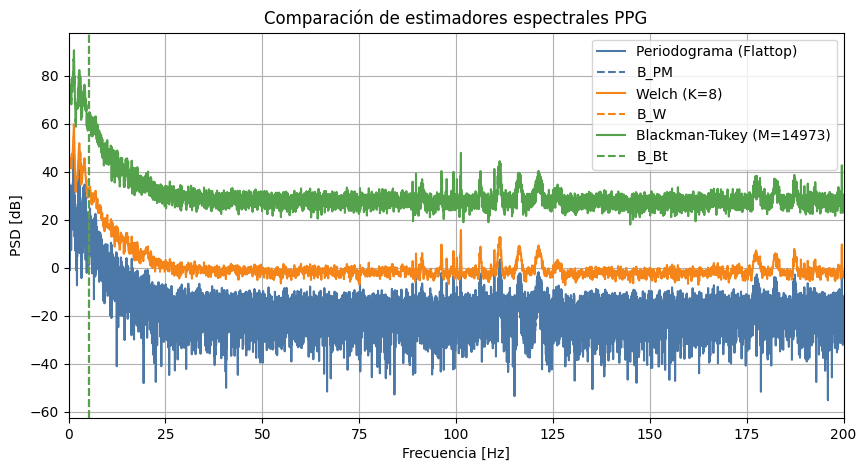


  Señal    |       Método       | Bandwidth [Hz] 
--------------------------------------------------
   PPG     |    Periodograma    |            5.35
   PPG     |       Welch        |            5.40
   PPG     |   Blackman-Tukey   |            5.40


In [75]:
#%% Graficos PSD PPG
plt.figure(figsize=(10,5))

# Periodograma ventaneado
plt.plot(f_ppg_pm,10*np.log10(2*Pppg_pm),label='Periodograma (Flattop)',color=color_pm)
plt.axvline(fcs_ppg_pm, color=color_pm, linestyle='--', label='B_PM')

# Welch
plt.plot(fppg_w,10*np.log10(Pppg_w),label=f'Welch (K={kppg})',color=color_w)
plt.axvline(fcs_ppg_w, color=color_w, linestyle='--', label='B_W')

# Blackman-Tukey
plt.plot(fppg_bt,10*np.log10(2*Pppg_bt),label=f'Blackman-Tukey (M={mppg})',color=color_bt)
plt.axvline(fcs_ppg_bt, color=color_bt, linestyle='--', label='B_Bt')


plt.xlim([0, fs_ppg/2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Comparación de estimadores espectrales PPG')
plt.grid(True)
plt.legend()
plt.show() 

print("\n{:^10} | {:^18} | {:^15}".format(
      "Señal", "Método", "Bandwidth [Hz]"))
print("-"*50)

datos = [
    ("PPG",   "Periodograma",   Bppg_pm),
    ("PPG",   "Welch",          Bppg_w),
    ("PPG",   "Blackman-Tukey", Bppg_bt),
]

for señal, metodo, bw in datos:
    print(f"{señal:^10} | {metodo:^18} | {bw:>15.2f}")

Los resultados son similares al anterior caso; El periodograma perjudica mucho la visualización de la PSD debido a su varianza. Los otros dos métodos presentan una mejora notable en ese aspecto a costa de una menor resolución especetral. En este caso, esta desventaja no parece afectar.

### Analisis de Audio ("La Cucaracha"):
#### Periodograma Ventaneado y audio Muestreado:
La señal de audio muestreada presenta características de señal pasabanda. Por eso, modificamos la forma de medir el ancho de banda de la misma. Gracias a eso notamos una serie de diferencia entre los métodos de estimación.

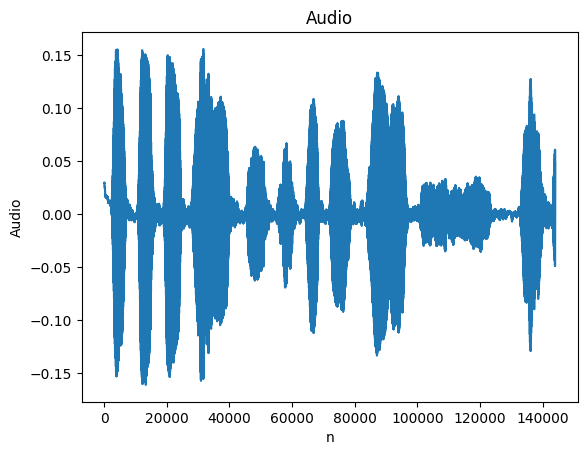

In [76]:
fs_aud, aud = sio.wavfile.read('la cucaracha.wav')
aud = aud - np.mean(aud) # Elimino la potencia de continua.
Naud = len(aud)
deltaf_aud = fs_aud/Naud

plt.figure()
plt.xlabel('n')
plt.ylabel('Audio')
plt.title('Audio')
plt.plot(aud)

#%% Audio con Periodograma ventaneado
aud_pm = aud * sig.windows.flattop(Naud)/ np.mean(sig.windows.flattop(Naud))
AUD_pm = np.fft.fft(aud_pm, axis = 0)/Naud
f_aud_pm = np.arange(start = 0, stop = fs_aud, step = deltaf_aud)
Paud_pm = np.abs(AUD_pm)**2

#Calculo de ancho de Banda
Baud_pm, fo_aud_pm, fcs_aud_pm, fci_aud_pm = bandWidth(Paud_pm[:Naud//2], deltaf = deltaf_aud, tipo = 'passband',  cota = cota)

#### Metodo de Welch:
##### Etapa de Selección de K:
Planteamos cuatro valores de K y seleccionamos el de nuestra preferencia. Para el audio volvemos a selecccionar K = 8 ya que presenta un buen balance entre una menor varianza y suficiente resolución espectral para discriminar los detalles.

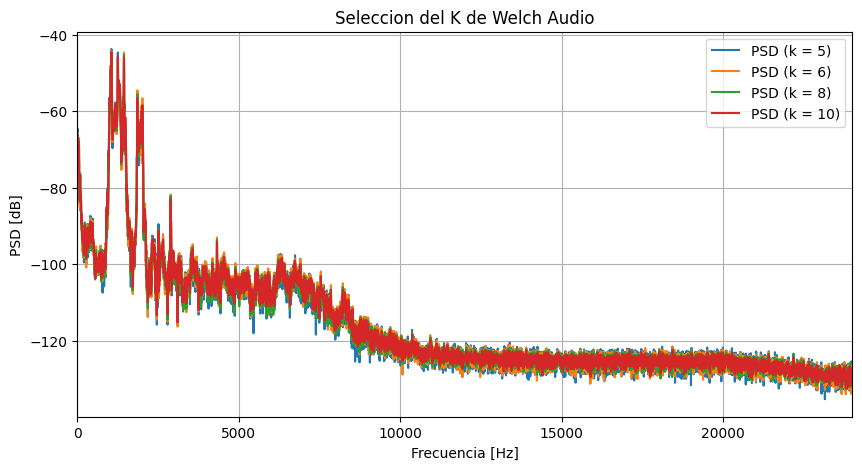

In [77]:
Kaud = [5, 6, 8, 10]

faud_k1, Paud_wk1 = sig.welch(aud, fs_aud, nperseg=Naud/Kaud[0], return_onesided = True)
faud_k2, Paud_wk2 = sig.welch(aud, fs_aud, nperseg=Naud/Kaud[1], return_onesided = True)
faud_k3, Paud_wk3 = sig.welch(aud, fs_aud, nperseg=Naud/Kaud[2], return_onesided = True)
faud_k4, Paud_wk4 = sig.welch(aud, fs_aud, nperseg=Naud/Kaud[3], return_onesided = True)

plt.figure(figsize=(10,5))
plt.plot(faud_k1,10*np.log10(Paud_wk1), label=f'PSD (k = {Kaud[0]})')
plt.plot(faud_k2,10*np.log10(Paud_wk2), label=f'PSD (k = {Kaud[1]})')
plt.plot(faud_k3,10*np.log10(Paud_wk3), label=f'PSD (k = {Kaud[2]})')
plt.plot(faud_k4,10*np.log10(Paud_wk4), label=f'PSD (k = {Kaud[3]})')


plt.xlim([0, fs_aud//2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Seleccion del K de Welch Audio')
plt.legend()
plt.grid()
plt.show()
#%% Calculo de ancho de Banda aud Welch
Paud_w = Paud_wk2
faud_w = faud_k2
kaud = 8
deltaf_aud_w = faud_w[1] - faud_w[0] 
Baud_w, fo_aud_w, fcs_aud_w, fci_aud_w = bandWidth(Paud_w, deltaf = deltaf_aud_w, tipo = 'passband',  cota = cota)

#### Método de Blackman-Tuckey:
Planteamos cuatro valores de M en funcion de N y seleccionamos el de nuestra preferencia. Para el audio selecccionamos M = N/3 ya que presentaba un buen balance entre una menor varianza y suficiente resolución espectral para discriminar los detalles.

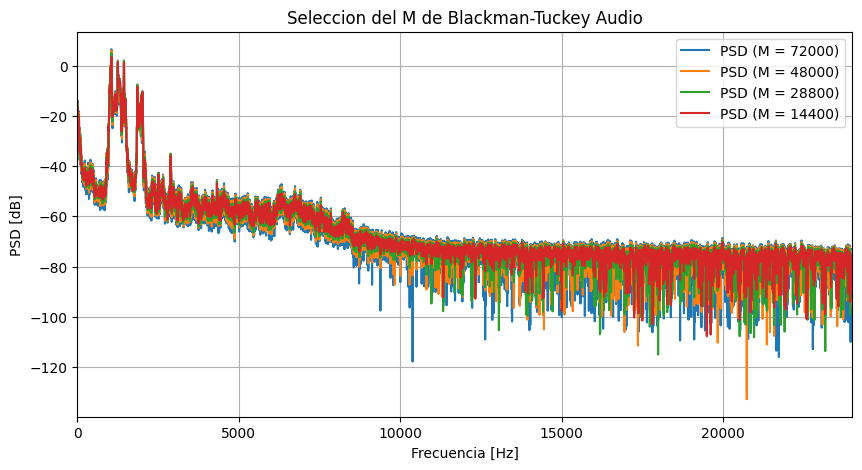

In [78]:
Maud = [Naud//2, Naud//3, Naud//5, Naud//10]

faud_M1, Paud_btM1 = blackman_tukey(aud,  fs = fs_aud, M = Maud[0])
faud_M2, Paud_btM2 = blackman_tukey(aud,  fs = fs_aud, M = Maud[1])
faud_M3, Paud_btM3 = blackman_tukey(aud,  fs = fs_aud, M = Maud[2])
faud_M4, Paud_btM4 = blackman_tukey(aud,  fs = fs_aud, M = Maud[3])

plt.figure(figsize=(10,5))
plt.plot(faud_M1,10*np.log10(Paud_btM1), label=f'PSD (M = {Maud[0]})')
plt.plot(faud_M2,10*np.log10(Paud_btM2), label=f'PSD (M = {Maud[1]})')
plt.plot(faud_M3,10*np.log10(Paud_btM3), label=f'PSD (M = {Maud[2]})')
plt.plot(faud_M4,10*np.log10(Paud_btM4), label=f'PSD (M = {Maud[3]})')

plt.xlim([0, fs_aud//2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Seleccion del M de Blackman-Tuckey Audio')
plt.legend()
plt.grid()
plt.show()

#%% Calculo de ancho de Banda Audio con Blackman-Tuckey
Paud_bt = Paud_btM2
faud_bt = faud_M2
maud = Maud[1]
deltaf_aud_bt = faud_bt[1] - faud_bt[0] 
Baud_bt, fo_aud_bt, fcs_aud_bt, fci_aud_bt = bandWidth(Paud_bt[:maud], deltaf = deltaf_aud_bt, tipo = 'passband',  cota = cota)

#### Graficos de PSD de una señal de Audio:

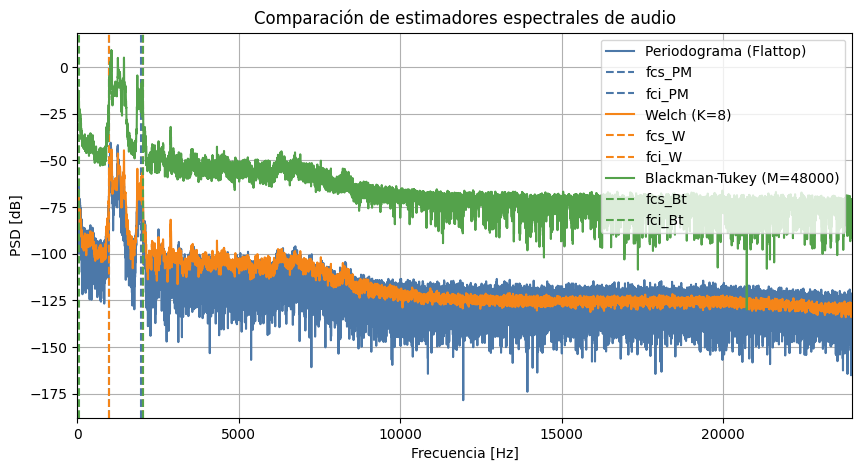


  Señal    |       Método       | Bandwidth [Hz] 
--------------------------------------------------
  Audio    |    Periodograma    |          982.00
  Audio    |       Welch        |         1036.00
  Audio    |   Blackman-Tukey   |         1968.02


In [79]:
#%% Graficos PSD Audio
plt.figure(figsize=(10,5))

# Periodograma ventaneado
plt.plot(f_aud_pm,10*np.log10(2*Paud_pm),label='Periodograma (Flattop)',color=color_pm)
plt.axvline(fcs_aud_pm, color=color_pm, linestyle='--', label='fcs_PM')
plt.axvline(fci_aud_pm, color=color_pm, linestyle='--', label='fci_PM')
# Welch
plt.plot(faud_w,10*np.log10(Paud_w),label=f'Welch (K={kaud})',color=color_w)
plt.axvline(fcs_aud_w, color=color_w, linestyle='--', label='fcs_W')
plt.axvline(fci_aud_w, color=color_w, linestyle='--', label='fci_W')

# Blackman-Tukey
plt.plot(faud_bt,10*np.log10(2*Paud_bt),label=f'Blackman-Tukey (M={maud})',color=color_bt)
plt.axvline(fcs_aud_bt, color=color_bt, linestyle='--', label='fcs_Bt')
plt.axvline(fci_aud_bt, color=color_bt, linestyle='--', label='fci_Bt')


plt.xlim([0, fs_aud/2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Comparación de estimadores espectrales de audio')
plt.grid(True)
plt.legend()
plt.show() 

print("\n{:^10} | {:^18} | {:^15}".format(
      "Señal", "Método", "Bandwidth [Hz]"))
print("-"*50)

datos = [
    ("Audio", "Periodograma",   Baud_pm),
    ("Audio", "Welch",          Baud_w),
    ("Audio", "Blackman-Tukey", Baud_bt)
]

for señal, metodo, bw in datos:
    print(f"{señal:^10} | {metodo:^18} | {bw:>15.2f}")

Al contrario con las señales bandabase anteriores, aquí podemos notar una gran diferencia entre el ancho de banda de Blackman-Tuckey y los otros dos. Esto se debe a que presenta una menor resolución espectral. La consecuencia es que los primeros bines ya contienen sufucuente energia para cubir una de las banda de la cota del ancho de banda. Como podemos observar en el gráfico, la frecuencia de corte inferior esta practicamante en 0Hz para BT. De ahi que el ancho de banda sea aproximadamente el doble al de los otros dos metodos. Este ejercicio nos permitió enfrentar una situación donde el deltaf fuese dominante para nuestra medición.
## Bonus:
Ahora repetimos el experimento sobre una señal muestreada de la nota LA en una guitarra electrica. La misma se conecto con su jack 6.2mm a la entrada para micrófono de la PC por medio de un adaptador. Entonces, se utilizó el DAC de la misma PC para realizar el muestreo.

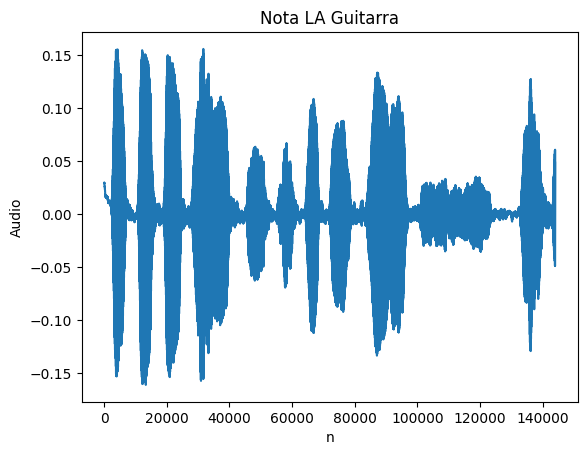

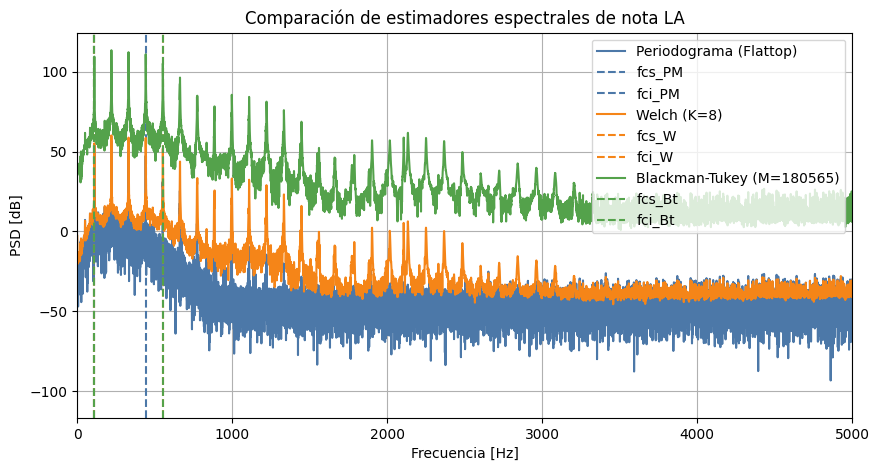


  Señal    |       Método       | Bandwidth [Hz] 
--------------------------------------------------
    LA     |    Periodograma    |          331.34
    LA     |       Welch        |          442.88
    LA     |   Blackman-Tukey   |          442.80


In [83]:
fs_la, la = sio.wavfile.read('NotaLaGuitarra.wav')
la = la - np.mean(la) # Elimino la potencia de continua.
Nla = len(la)
deltaf_la = fs_la/Nla
cota = 0.95

plt.figure()
plt.xlabel('n')
plt.ylabel('Audio')
plt.title('Nota LA Guitarra')
plt.plot(aud)

#%% Nota LA con Periodograma ventaneado
la_pm = la * sig.windows.flattop(Nla)/ np.mean(sig.windows.flattop(Nla))
LA_pm = np.fft.fft(la_pm, axis = 0)/Nla
f_la_pm = np.arange(start = 0, stop = fs_la, step = deltaf_la)
Pla_pm = np.abs(LA_pm)**2

#Calculo de ancho de Banda
Bla_pm, fo_la_pm, fcs_la_pm, fci_la_pm = bandWidth(Pla_pm[:Nla//2], deltaf = deltaf_la, tipo = 'passband',  cota = cota)

#%% Nota LA con Welch
kla = 8
fla_w, Pla_w = sig.welch(la, fs_la, nperseg=Nla/kla, return_onesided = True)
deltaf_la_w = fla_w[1] - fla_w[0] 
Bla_w, fo_la_w, fcs_la_w, fci_la_w = bandWidth(Pla_w, deltaf = deltaf_la_w, tipo = 'passband',  cota = cota)

#%% Nota LA con Blackman-Tuckey
mla = Nla//3
fla_bt, Pla_bt = blackman_tukey(la,  fs = fs_la, M = mla)
deltaf_la_bt = fla_bt[1] - fla_bt[0] 
Bla_bt, fo_la_bt, fcs_la_bt, fci_la_bt = bandWidth(Pla_bt[:mla], deltaf = deltaf_la_bt, tipo = 'passband',  cota = cota)

#%% Graficos Nota LA
plt.figure(figsize=(10,5))

# Periodograma ventaneado
plt.plot(f_la_pm,10*np.log10(2*Pla_pm),label='Periodograma (Flattop)',color=color_pm)
plt.axvline(fcs_la_pm, color=color_pm, linestyle='--', label='fcs_PM')
plt.axvline(fci_la_pm, color=color_pm, linestyle='--', label='fci_PM')
# Welch
plt.plot(fla_w,10*np.log10(Pla_w),label=f'Welch (K={kla})',color=color_w)
plt.axvline(fcs_la_w, color=color_w, linestyle='--', label='fcs_W')
plt.axvline(fci_la_w, color=color_w, linestyle='--', label='fci_W')

# Blackman-Tukey
plt.plot(fla_bt,10*np.log10(2*Pla_bt),label=f'Blackman-Tukey (M={mla})',color=color_bt)
plt.axvline(fcs_la_bt, color=color_bt, linestyle='--', label='fcs_Bt')
plt.axvline(fci_la_bt, color=color_bt, linestyle='--', label='fci_Bt')


plt.xlim([0, 5000])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.title('Comparación de estimadores espectrales de nota LA')
plt.grid(True)
plt.legend()
plt.show() 

print("\n{:^10} | {:^18} | {:^15}".format(
      "Señal", "Método", "Bandwidth [Hz]"))
print("-"*50)

datos = [
    ("LA",   "Periodograma",   Bla_pm),
    ("LA",   "Welch",          Bla_w),
    ("LA",   "Blackman-Tukey", Bla_bt),
]

for señal, metodo, bw in datos:
    print(f"{señal:^10} | {metodo:^18} | {bw:>15.2f}")

Resultaba interesante aplicar los diferentes metodos de estimación de espectro a un instrumento musical debido al gran contenido de armonicos que presentan. Como se puede observar, al bajar la varianza mediante Welch o BT, logramos detectar los armonicos producidos por el sonido de una sola cuerda quue en el caso del periodograma se "esconden" en el "ruido" de la varianza. En cuanto al ancho de banda, notamos que todos los metodos colocan la fci en aproximadamente el mismo punto que corresponde con la señal fundamental (La2 = 110Hz). Por otro lado, el periodograma toma hasta el tercer armonico mientras que los otros dos metodos toman hasta el cuarto para una cota del 95%. 